## Modeling — SMOTE + Bayesian Optimization (F2 At-Risk)

Mỗi `prediction_point` train một model riêng:
1. **SMOTE** — oversample Fail và Withdrawn, tỷ lệ tăng `(1 + x) * N_current` với `x ∈ [0.1, 0.9]`
2. **Bayesian Optimization** — tìm đồng thời: hyperparameter mô hình + SMOTE ratio + class weight
3. **Metric**: F2 score của Fail và Withdrawn (β=2, nhấn mạnh recall)
4. **Evaluate** — test với `predict()` thông thường, không threshold tuning

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import RANDOM_SEED, SNAPSHOTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, fbeta_score,
)

In [2]:
data_dir = Path('../data/processed')

X_train    = pd.read_parquet(data_dir / 'X_train.parquet')
X_test     = pd.read_parquet(data_dir / 'X_test.parquet')
y_train    = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test     = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

TARGET_NAMES = ['Fail', 'Pass', 'Withdrawn']

print('X_train:', X_train.shape)
print('Features:', list(X_train.columns))
print('Snapshots:', sorted(train_meta['prediction_point'].unique()))

X_train: (142384, 14)
Features: ['imd_band', 'highest_education', 'num_of_prev_attempts', 'studied_credits', 'disability', 'active_weeks', 'avg_weekly_clicks', 'num_due', 'num_submitted', 'avg_score', 'submission_rate', 'num_failed', 'avg_days_early', 'no_submission_despite_due']
Snapshots: [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(150), np.int64(180), np.int64(210), np.int64(240)]


### Helper functions

In [3]:
def get_snapshot_data(T):
    mask_tr = train_meta['prediction_point'].values == T
    mask_te = test_meta['prediction_point'].values == T
    return (
        X_train[mask_tr].reset_index(drop=True),
        X_test[mask_te].reset_index(drop=True),
        y_train[mask_tr].reset_index(drop=True),
        y_test[mask_te].reset_index(drop=True),
    )


def safe_smote(X, y, ratio_fail=0.5, ratio_withdrawn=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio ∈ [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_fail = (y_s == 0).sum()
    n_with = (y_s == 2).sum()
    target = {
        0: int((1 + ratio_fail) * n_fail),
        2: int((1 + ratio_withdrawn) * n_with),
    }
    k = max(1, min(5, n_with - 1, n_fail - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — tất cả prediction_point

**Ước tính runtime:** ~1–2 giờ (8 mốc × 30 trials × 3 folds + 1 lần retrain mỗi mốc)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (max_iter, learning_rate, max_depth, ...)
- SMOTE ratio cho Fail và Withdrawn (`smote_ratio_fail`, `smote_ratio_withdrawn` ∈ [0.1, 0.9])
- Class weight cho Fail (`w_fail` ∈ [1, 5]) và Withdrawn (`w_withdrawn` ∈ [1, 8])


############################################################
  PREDICTION POINT = 30 days
############################################################
Train: 19,988 | Test: 5,043


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4561
SMOTE  → Fail: +0.67x | Withdrawn: +0.28x
Weight → Fail: 4.68 | Withdrawn: 7.16

  T=30
              precision    recall  f1-score   support

        Fail      0.354     0.526     0.423      1274
        Pass      0.834     0.309     0.451      2804
   Withdrawn      0.248     0.543     0.341       965

    accuracy                          0.409      5043
   macro avg      0.479     0.459     0.405      5043
weighted avg      0.601     0.409     0.423      5043



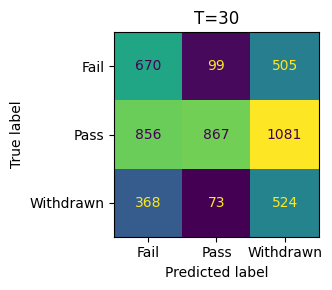


############################################################
  PREDICTION POINT = 60 days
############################################################
Train: 19,123 | Test: 4,835


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4585
SMOTE  → Fail: +0.87x | Withdrawn: +0.87x
Weight → Fail: 4.79 | Withdrawn: 7.14

  T=60
              precision    recall  f1-score   support

        Fail      0.389     0.664     0.490      1274
        Pass      0.888     0.351     0.503      2804
   Withdrawn      0.216     0.443     0.290       757

    accuracy                          0.448      4835
   macro avg      0.498     0.486     0.428      4835
weighted avg      0.651     0.448     0.466      4835



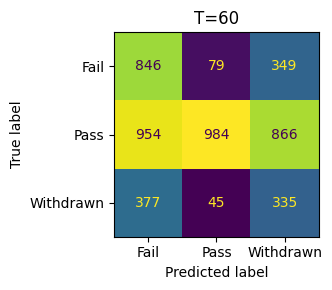


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4647
SMOTE  → Fail: +0.89x | Withdrawn: +0.87x
Weight → Fail: 4.23 | Withdrawn: 7.97

  T=90
              precision    recall  f1-score   support

        Fail      0.410     0.688     0.514      1274
        Pass      0.904     0.429     0.582      2804
   Withdrawn      0.185     0.374     0.248       602

    accuracy                          0.492      4680
   macro avg      0.500     0.497     0.448      4680
weighted avg      0.677     0.492     0.520      4680



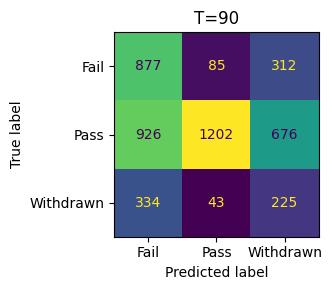


############################################################
  PREDICTION POINT = 120 days
############################################################
Train: 17,917 | Test: 4,518


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4581
SMOTE  → Fail: +0.59x | Withdrawn: +0.10x
Weight → Fail: 4.02 | Withdrawn: 7.99

  T=120
              precision    recall  f1-score   support

        Fail      0.492     0.734     0.589      1274
        Pass      0.898     0.672     0.769      2804
   Withdrawn      0.204     0.241     0.221       440

    accuracy                          0.648      4518
   macro avg      0.532     0.549     0.526      4518
weighted avg      0.716     0.648     0.665      4518



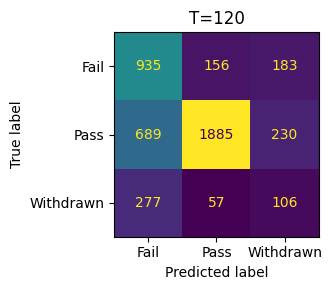


############################################################
  PREDICTION POINT = 150 days
############################################################
Train: 17,386 | Test: 4,363


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4648
SMOTE  → Fail: +0.29x | Withdrawn: +0.29x
Weight → Fail: 2.89 | Withdrawn: 6.84

  T=150
              precision    recall  f1-score   support

        Fail      0.608     0.763     0.677      1274
        Pass      0.901     0.792     0.843      2804
   Withdrawn      0.167     0.175     0.171       285

    accuracy                          0.743      4363
   macro avg      0.559     0.577     0.564      4363
weighted avg      0.767     0.743     0.751      4363



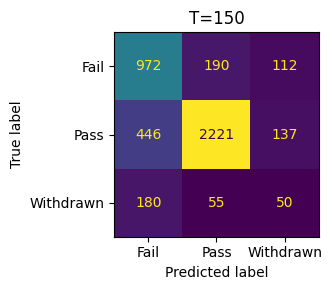


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4590
SMOTE  → Fail: +0.28x | Withdrawn: +0.73x
Weight → Fail: 1.72 | Withdrawn: 5.39

  T=180
              precision    recall  f1-score   support

        Fail      0.725     0.762     0.743      1274
        Pass      0.902     0.881     0.891      2804
   Withdrawn      0.138     0.139     0.138       137

    accuracy                          0.821      4215
   macro avg      0.588     0.594     0.591      4215
weighted avg      0.824     0.821     0.822      4215



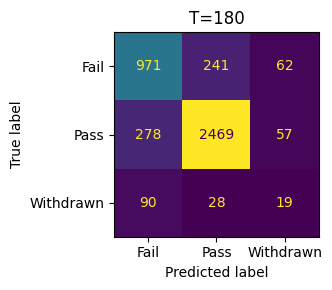


############################################################
  PREDICTION POINT = 210 days
############################################################
Train: 16,486 | Test: 4,162


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4566
SMOTE  → Fail: +0.10x | Withdrawn: +0.76x
Weight → Fail: 2.13 | Withdrawn: 7.47

  T=210
              precision    recall  f1-score   support

        Fail      0.736     0.811     0.771      1274
        Pass      0.919     0.883     0.901      2804
   Withdrawn      0.136     0.107     0.120        84

    accuracy                          0.845      4162
   macro avg      0.597     0.600     0.597      4162
weighted avg      0.847     0.845     0.845      4162



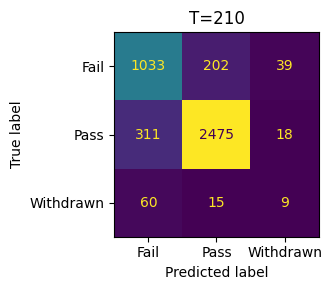


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.5281
SMOTE  → Fail: +0.39x | Withdrawn: +0.90x
Weight → Fail: 1.91 | Withdrawn: 5.93

  T=240
              precision    recall  f1-score   support

        Fail      0.799     0.843     0.820      1274
        Pass      0.932     0.907     0.919      2804
   Withdrawn      0.263     0.312     0.286        16

    accuracy                          0.885      4094
   macro avg      0.665     0.688     0.675      4094
weighted avg      0.888     0.885     0.886      4094



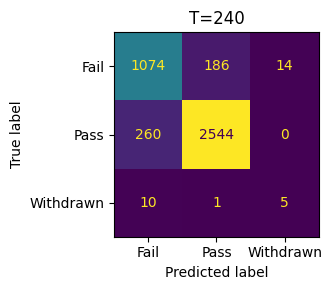


--- Tổng hợp ---


,prediction_point,accuracy,recall_fail,recall_pass,recall_withdrawn,macro_recall,precision_fail,precision_withdrawn,f2_at_risk
0,30,0.4087,0.5259,0.3092,0.5430,0.4594,0.3537,0.2483,0.4591
1,60,0.4478,0.6641,0.3509,0.4425,0.4858,0.3886,0.2161,0.4737
2,90,0.4923,0.6884,0.4287,0.3738,0.4969,0.4104,0.1855,0.4585
3,120,0.6476,0.7339,0.6723,0.2409,0.5490,0.4918,0.2042,0.4504
4,150,0.7433,0.7630,0.7921,0.1754,0.5768,0.6083,0.1672,0.4499
5,180,0.8206,0.7622,0.8805,0.1387,0.5938,0.7252,0.1377,0.4465
6,210,0.8450,0.8108,0.8827,0.1071,0.6002,0.7358,0.1364,0.4533
7,240,0.8850,0.8430,0.9073,0.3125,0.6876,0.7991,0.2632,0.5675


In [4]:
models  = {}
results = []

for T in SNAPSHOTS:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'max_iter':          trial.suggest_int('max_iter', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
            'random_state':      RANDOM_SEED,
        }
        r_fail = trial.suggest_float('smote_ratio_fail', 0.1, 0.9)
        r_with = trial.suggest_float('smote_ratio_withdrawn', 0.1, 0.9)
        w_fail = trial.suggest_float('w_fail', 1.0, 5.0)
        w_with = trial.suggest_float('w_withdrawn', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            Xf_sm, yf_sm = safe_smote(Xf_tr, yf_tr, r_fail, r_with)
            m = HistGradientBoostingClassifier(
                **params,
                class_weight={0: w_fail, 1: 1.0, 2: w_with},
            )
            m.fit(Xf_sm, yf_sm)

            score = fbeta_score(
                yf_val, m.predict(Xf_val),
                beta=2, average='macro', labels=[0, 2], zero_division=0,
            )
            fold_scores.append(score)
        return np.mean(fold_scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best = study.best_params
    print(f'Best F2 CV: {study.best_value:.4f}')
    print(f'SMOTE  → Fail: +{best["smote_ratio_fail"]:.2f}x | Withdrawn: +{best["smote_ratio_withdrawn"]:.2f}x')
    print(f'Weight → Fail: {best["w_fail"]:.2f} | Withdrawn: {best["w_withdrawn"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    X_sm, y_sm = safe_smote(
        X_tr, y_tr,
        ratio_fail=best['smote_ratio_fail'],
        ratio_withdrawn=best['smote_ratio_withdrawn'],
    )
    model_final = HistGradientBoostingClassifier(
        max_iter=best['max_iter'],
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        l2_regularization=best['l2_regularization'],
        max_leaf_nodes=best['max_leaf_nodes'],
        class_weight={0: best['w_fail'], 1: 1.0, 2: best['w_withdrawn']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te))
    evaluate_full(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    results.append({
        'prediction_point':    T,
        'accuracy':            round(accuracy_score(y_te, y_pred), 4),
        'recall_fail':         round(recalls[0], 4),
        'recall_pass':         round(recalls[1], 4),
        'recall_withdrawn':    round(recalls[2], 4),
        'macro_recall':        round(recalls.mean(), 4),
        'precision_fail':      round(precisions[0], 4),
        'precision_withdrawn': round(precisions[2], 4),
        'f2_at_risk':          round(fbeta_score(y_te, y_pred, beta=2, average='macro',
                                                  labels=[0, 2], zero_division=0), 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df

---

## Trực quan hóa theo thời gian

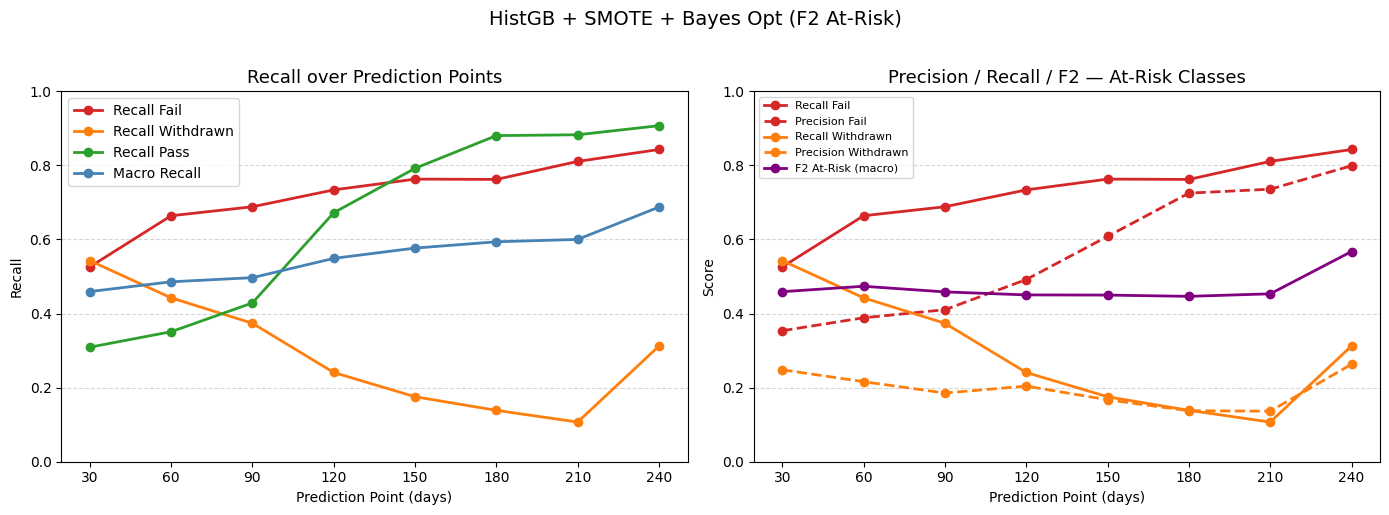

In [5]:
pts = results_df['prediction_point']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Recall ---
for col, label, color in [
    ('recall_fail',      'Recall Fail',      'tab:red'),
    ('recall_withdrawn', 'Recall Withdrawn', 'tab:orange'),
    ('recall_pass',      'Recall Pass',      'tab:green'),
    ('macro_recall',     'Macro Recall',     'steelblue'),
]:
    axes[0].plot(pts, results_df[col], marker='o', label=label, color=color, linewidth=2)
axes[0].set_title('Recall over Prediction Points', fontsize=13)
axes[0].set_xlabel('Prediction Point (days)')
axes[0].set_ylabel('Recall')
axes[0].set_xticks(SNAPSHOTS)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Precision / Recall / F2 cho at-risk classes ---
for col, label, color, ls in [
    ('recall_fail',         'Recall Fail',         'tab:red',    '-'),
    ('precision_fail',      'Precision Fail',      'tab:red',    '--'),
    ('recall_withdrawn',    'Recall Withdrawn',    'tab:orange', '-'),
    ('precision_withdrawn', 'Precision Withdrawn', 'tab:orange', '--'),
    ('f2_at_risk',          'F2 At-Risk (macro)',  'purple',     '-'),
]:
    axes[1].plot(pts, results_df[col], marker='o', label=label,
                 color=color, linestyle=ls, linewidth=2)
axes[1].set_title('Precision / Recall / F2 — At-Risk Classes', fontsize=13)
axes[1].set_xlabel('Prediction Point (days)')
axes[1].set_ylabel('Score')
axes[1].set_xticks(SNAPSHOTS)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('HistGB + SMOTE + Bayes Opt (F2 At-Risk)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Feature Importance — Permutation Importance

Tính permutation importance trên test set cho từng `prediction_point`, dùng F2 at-risk (Fail+Withdrawn, β=2) làm scoring để đo đúng mức độ ảnh hưởng tới mục tiêu chính.

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

f2_at_risk_scorer = make_scorer(
    fbeta_score, beta=2, average='macro', labels=[0, 2], zero_division=0,
)

importance_records = []

for T in SNAPSHOTS:
    _, X_te_raw, _, y_te = get_snapshot_data(T)
    X_te = X_te_raw.fillna(0)

    result = permutation_importance(
        models[T], X_te, y_te,
        scoring=f2_at_risk_scorer,
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    for feat, mean_imp, std_imp in zip(X_te.columns, result.importances_mean, result.importances_std):
        importance_records.append({
            'prediction_point': T,
            'feature': feat,
            'importance_mean': mean_imp,
            'importance_std': std_imp,
        })

importance_df = pd.DataFrame(importance_records)
importance_df

In [ ]:
pivot = importance_df.pivot(index='feature', columns='prediction_point', values='importance_mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Prediction Point (days)')
ax.set_title('Permutation Importance (mean drop in F2 At-Risk) theo feature x mốc thời gian')
fig.colorbar(im, ax=ax, label='Importance (mean)')
plt.tight_layout()
plt.show()

# Top feature trung bình toàn bộ mốc
top_overall = pivot.mean(axis=1).sort_values(ascending=False)
print('\nTop feature theo importance trung bình (tất cả mốc):')
print(top_overall)